# BNP Paribas- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [2]:
# Configurações de estilo para os gráficos da apresentação
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

<a class="anchor" id="1.1 Import Libraries">

## 1.2 Data Loading
    
</a>

In [3]:
#file_path_BNP = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\crc.parquet"
file_path_BNP_teste = r"C:\Users\Catarina\Documents\GitHub\BNP-Paribas\Preprocessed_dataset_BNP2_teste.csv"

# Ler o ficheiro parquet
#BNP = pd.read_csv(file_path_BNP)
BNP_teste = pd.read_csv(file_path_BNP_teste)

# Carregar o dataset pré-processado
df = pd.read_csv(file_path_BNP_teste)

In [4]:
# Converter colunas temporais
date_cols = ["DCREAT", "CLOSE_DATE", "NEXT_DOSSIER_DATE"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")

Dataset carregado: 185600 linhas e 55 colunas.


<a class="anchor" id="1.1 Import Libraries">

## 2. Target Engineering
    
</a>

In [6]:
# 1. Converter o Target para Binário (0 e 1)
# Usamos .fillna(0) porque os contratos abertos ainda não têm churn definido
df['TARGET'] = df['CHURN'].fillna(0).astype(int)

# 2. SELEÇÃO ANTI-LEAKAGE E REMOÇÃO DE IDs
# incluir aqui todas as colunas que identificam o cliente ou o contrato
leaky_features = [
    'CHURN', 'NEXT_DOSSIER_DATE', 'DAYS_TO_NEXT', 
    'CHURN_DATE', 'days_to_churn', 'event', 'duration', 'DOSSIER_DURATION_DAYS'
]

# Identificadores que não devem ir para o treino
ids_to_drop = ['CONTRIB', 'DCREAT', 'CLOSE_DATE', 'OBS_END_DATE']

# Criamos X (features) e y (alvo)
# O código verifica se a coluna existe antes de tentar fazer o drop para evitar erros
cols_to_drop = [col for col in leaky_features + ids_to_drop if col in df.columns]
X = df.drop(columns=[col for col in leaky_features + ids_to_drop + ['TARGET'] if col in df.columns])
y = df['TARGET']

print(f"Colunas removidas: {cols_to_drop}")

Colunas removidas: ['CHURN', 'NEXT_DOSSIER_DATE', 'DAYS_TO_NEXT', 'DOSSIER_DURATION_DAYS', 'CONTRIB', 'DCREAT', 'CLOSE_DATE', 'OBS_END_DATE']


<a class="anchor" id="1.1 Import Libraries">

## 3. Time-Based Split
    
</a>

In [7]:
# 1. Identificar quem é PASSADO (histórico) e quem é FUTURO (teste real) usando o df original
historical_idx = df[df['CLOSE_DATE'].notna()].index
test_idx = df[df['CLOSE_DATE'].isna()].index

# 2. Definir o Ponto de Corte no histórico para a Validação (últimos 4 meses)
historical_dates = df.loc[historical_idx, 'CLOSE_DATE']
cutoff_date = historical_dates.max() - pd.DateOffset(months=4)

# Criar as máscaras (filtros) para separar Treino de Validação
train_idx = historical_dates[historical_dates < cutoff_date].index
val_idx = historical_dates[historical_dates >= cutoff_date].index

# 3. CRIAR OS SETS USANDO O X e o Y (que já estão limpos!)
X_train = X.loc[train_idx]
y_train = y.loc[train_idx]

X_val = X.loc[val_idx]
y_val = y.loc[val_idx]

X_test = X.loc[test_idx]

print(f"Treino: {X_train.shape[0]} linhas | Validação: {X_val.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")

Treino: 63118 linhas | Validação: 13528 linhas | Teste: 108954 linhas


## Encoding

In [8]:
# --- CONVERSÃO DE TEXTO PARA NÚMERO ---

# Selecionar todas as colunas que são 'object' (texto)
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    # Calculamos a frequência no treino
    freq_map = X_train[col].value_counts(normalize=True)
    
    # Aplicamos ao treino e à validação
    X_train[col] = X_train[col].map(freq_map)
    X_val[col] = X_val[col].map(freq_map)
    
    # Se houver valores novos na validação que não existiam no treino, pomos 0
    X_val[col] = X_val[col].fillna(0)

print(f"Colunas convertidas: {list(cat_cols)}")

Colunas convertidas: ['DOSSIER', 'DCRD_0', 'POLE', 'PRODALP', 'PAGAMENTO', 'NATIO', 'MODCONTACTO', 'kp_sqe', 'sdem_SITFAM', 'sdem_HABITAT']


In [9]:
X_train.head()

,DOSSIER,is_san,is_sol,DCRD_0,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,...,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,0.000016,1,0,0.078852,84,3,19,1,158.359889,0.0,...,0.027932,2,1.0,120.0,0.033333,10,0.199230,0.273916,33,0.272727
3,0.000016,0,1,0.105913,60,21,21,0,424.699203,0.0,...,0.716689,1,1.0,60.0,0.178571,8,0.406081,0.358741,44,0.166667
4,0.000016,0,1,0.105913,60,21,21,0,184.214593,0.0,...,0.716689,1,1.0,60.0,0.178571,8,0.406081,0.358741,44,0.166667
5,0.000016,1,0,0.283184,72,34,34,0,56.017772,0.0,...,0.716689,1,1.0,0.0,0.000000,3,0.199230,0.358741,69,0.000000
8,0.000016,0,1,0.105913,84,24,24,0,274.916857,0.0,...,0.716689,1,1.0,0.0,0.000000,7,0.020184,0.266374,74,0.000000


In [10]:
# Identificar colunas que são datas
date_cols = X_train.select_dtypes(include=['datetime64']).columns

# Remover essas colunas
X_train = X_train.drop(columns=date_cols)
X_val = X_val.drop(columns=date_cols)
X_test = X_test.drop(columns=date_cols)

print(f"Colunas de data removidas: {list(date_cols)}")

# 3. Agora a variância corre sem problemas
variances = X_train.var()
low_variance_cols = variances[variances < 0.01].index
# ... continuar o drop das low_variance_cols

Colunas de data removidas: []


<a class="anchor" id="1.1 Import Libraries">

## 4. Feature Selection
    
</a>

### 4.1 Filter Methods

#### Variance

In [10]:
# Agora o .var() já consegue calcular tudo
variances = X_train.var()

# Identificar colunas com quase nenhuma variação (threshold 0.01)
low_variance_cols = variances[variances < 0.01].index

print(low_variance_cols)

Index(['DOSSIER', 'CRD_min', 'NATIO', 'sdem_HABITAT'], dtype='object')


### Correlation Matrix

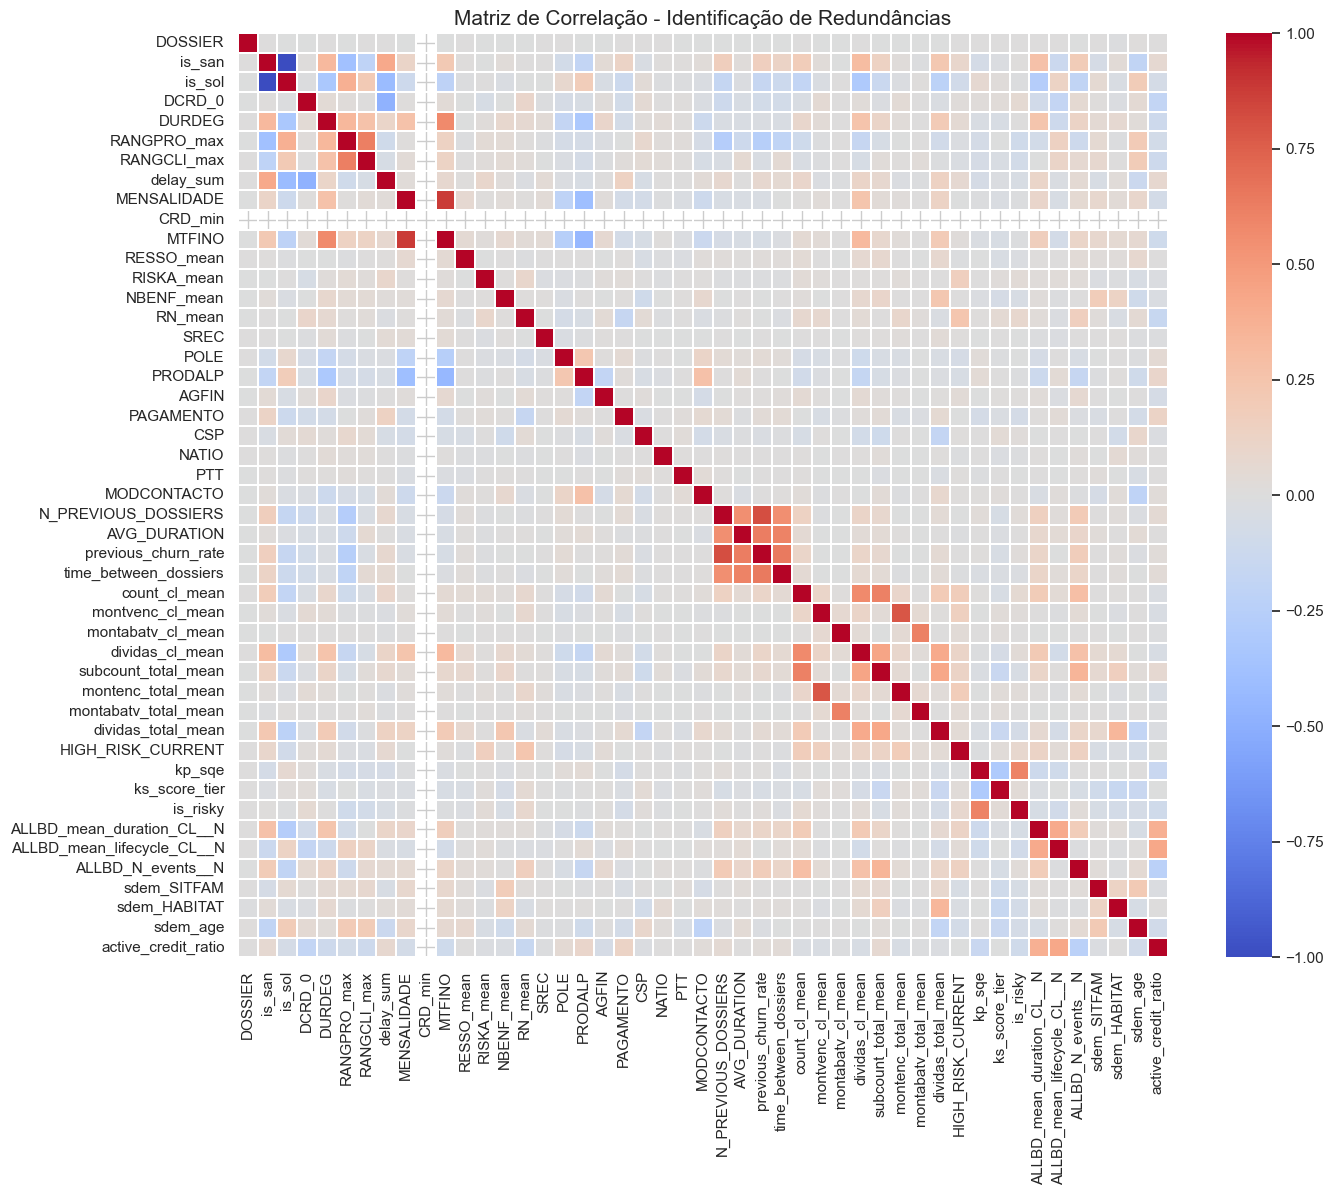

In [11]:
# 1. Calcular a matriz de correlação
corr_matrix = X_train.corr()

# 2. Visualização com Heatmap
plt.figure(figsize=(15, 12))
# Usamos um mapa de cores divergente (coolwarm) para distinguir correlações positivas e negativas
sns.heatmap(corr_matrix, 
            annot=False, # Definimos como False porque com muitas colunas os números não se leem
            cmap='coolwarm', 
            vmin=-1, vmax=1, # Escala fixa de -1 a 1
            linewidths=0.1)

plt.title("Matriz de Correlação - Identificação de Redundâncias", fontsize=15)
plt.show()

### MI

In [12]:
# 1. Computing Mutual Information (MI) para CLASSIFICAÇÃO
# Mudamos para mutual_info_classif porque o TARGET (Churn) é 0 ou 1
print("A calcular MI no dataset completo... (pode demorar)")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 2. Criar o DataFrame para associar nomes e scores
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3. Exibir as top 15
print(mi_df.head(15))

# 4. Selecionar os nomes das top 15
top_mi_features = mi_df.head(15)['Feature'].tolist()

# 5. Criar o dataset reduzido
X_train_mi = X_train[top_mi_features]
X_val_mi = X_val[top_mi_features] # Não esqueças de aplicar também à validação!

A calcular MI no dataset completo... (pode demorar)
                       Feature  MI_Score
41  ALLBD_mean_lifecycle_CL__N  0.112018
40   ALLBD_mean_duration_CL__N  0.090509
11                  RESSO_mean  0.079335
31             dividas_cl_mean  0.071445
35          dividas_total_mean  0.056764
1                       is_san  0.049088
46         active_credit_ratio  0.046349
2                       is_sol  0.045306
28               count_cl_mean  0.044146
7                    delay_sum  0.040265
26         previous_churn_rate  0.033091
32         subcount_total_mean  0.031684
5                  RANGPRO_max  0.026583
3                       DCRD_0  0.026444
8                  MENSALIDADE  0.020809


## Wrapper Methods

In [11]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# 1. Definir o modelo "professor" 
# Usamos Random Forest porque lida bem com relações não-lineares e não precisa de scaling
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)

# 2. Configurar o RFE
# n_features_to_select: quantas queremos no final (vamos pedir 15 para começar)
# step: remove 5 de cada vez para ser mais rápido
selector = RFE(estimator=rf, n_features_to_select=15, step=5, verbose=1)

In [12]:
print("A treinar o modelo de seleção (RFE)...")
selector.fit(X_train, y_train)

# 4. Extrair os resultados
selected_features = X_train.columns[selector.get_support()].tolist()
ranking = pd.DataFrame({'Feature': X_train.columns, 'Ranking': selector.ranking_}).sort_values('Ranking')

print(f"\n✅ O modelo escolheu estas 15 variáveis: \n{selected_features}")

A treinar o modelo de seleção (RFE)...
Fitting estimator with 47 features.
Fitting estimator with 42 features.
Fitting estimator with 37 features.
Fitting estimator with 32 features.
Fitting estimator with 27 features.
Fitting estimator with 22 features.
Fitting estimator with 17 features.

✅ O modelo escolheu estas 15 variáveis: 
['is_san', 'is_sol', 'DCRD_0', 'RANGPRO_max', 'delay_sum', 'RESSO_mean', 'AVG_DURATION', 'previous_churn_rate', 'time_between_dossiers', 'count_cl_mean', 'dividas_cl_mean', 'dividas_total_mean', 'ALLBD_mean_duration_CL__N', 'ALLBD_mean_lifecycle_CL__N', 'active_credit_ratio']


### Embedded methods

In [13]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# --- 6.2.1 Random Forest Importance ---
rf_embedded = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_embedded.fit(X_train, y_train)
rf_importance = pd.Series(rf_embedded.feature_importances_, index=X_train.columns)


In [14]:
# --- 6.2.2 XGBoost Importance ---
# Calculamos o peso para classes desequilibradas (como o João fez)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_embedded = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, 
                             scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
xgb_embedded.fit(X_train, y_train)
xgb_importance = pd.Series(xgb_embedded.feature_importances_, index=X_train.columns)

In [15]:
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

# 1. Criar dataset de sobrevivência escalado
surv_cols = X_train.columns.tolist() + ['duration', 'event']
df_surv_embedded = df.loc[X_train.index, surv_cols].copy()

# 2. Escalar apenas as features (X), não a duração/evento
scaler = StandardScaler()
df_surv_embedded[X_train.columns] = scaler.fit_transform(df_surv_embedded[X_train.columns])

# 3. Treinar Cox com Penalização L1 (Lasso)
cph_embedded = CoxPHFitter(penalizer=0.1, l1_ratio=1.0) # l1_ratio=1 é puro Lasso
cph_embedded.fit(df_surv_embedded, duration_col='duration', event_col='event')

# Extrair coeficientes absolutos como medida de importância
cox_importance = np.abs(cph_embedded.summary['coef'])

KeyError: "['duration', 'event'] not in index"